# Xenium In Situ Analysis of Alzheimer's Disease Mouse Model Brain Coronal Sections from One Hemisphere Over a Time Course

Author: Francesca Drummer, Marco Varrone

<strong><span style="color:red">Download dataset <a href="https://www.10xgenomics.com/datasets/xenium-in-situ-analysis-of-alzheimers-disease-mouse-model-brain-coronal-sections-from-one-hemisphere-over-a-time-course-1-standard">here</a></span></strong>

In [1]:
import warnings
warnings.filterwarnings("ignore")

#import squidpy as sq
import scanpy as sc
import spatialdata as sd
#import spatialdata_io
import anndata as ad
from pathlib import Path

import pandas as pd
import os
#import tenx_method_nb_helper_functions as hf

# Global variables

In [2]:
sample_path = #".."
experiments = ["Xenium_V1_FFPE_TgCRND8_2_5_months_outs", "Xenium_V1_FFPE_TgCRND8_5_7_months_outs", "Xenium_V1_FFPE_TgCRND8_17_9_months_outs",
               "Xenium_V1_FFPE_wildtype_2_5_months_outs", "Xenium_V1_FFPE_wildtype_5_7_months_outs", "Xenium_V1_FFPE_wildtype_13_4_months_outs"]

# Load SpatialData object

In [ ]:
anndata_list = []
spatialdata_dict = {}
obs_names = []
start = 0
for name in experiments:    
    xenium_data = spatialdata_io.xenium(os.path.join(sample_path, name),cells_boundaries=False,nucleus_boundaries=False,)
    spatialdata_dict[name] = xenium_data
    adata = xenium_data.table
    stop = start + len(adata.obs_names) 
    obs_names = [str(i) for i in range(start, stop)]
    start = stop
    adata.obs_names = obs_names
    parts = name.split("_")
    adata.obs['condition'] = parts[3] 
    adata.obs['time'] = "_".join(parts[4:6])
    adata.write(f'{sample_path}/anndata/{name}.h5ad')
    anndata_list.append(adata)
    

## Merge conditions

In [ ]:
#xenium_data = sd.concatenate(spatialdata_list)

In [ ]:
adata = anndata_list[0]
adata = adata.concatenate(
    anndata_list[1:],
    batch_key="batch_key",
    batch_categories=[str(i) for i in range(len(anndata_list))],  
    )
adata

In [ ]:
adata.obs.groupby(['time', 'condition']).size()

In [7]:
adata.write(f'{sample_path}/anndata/xenium_mouse_ad.h5ad')

## Cell type annotation

Cell type annotation with marker genes from [supp document](https://pages.10xgenomics.com/rs/446-PBO-704/images/10x_LIT000210_App-Note_Xenium-In-Situ_Letter_Digital.pdf)

In [3]:
adata = ad.read_h5ad(f'{sample_path}/anndata/xenium_mouse_ad.h5ad')
adata

AnnData object with n_obs × n_vars = 351714 × 347
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'condition', 'time', 'batch_key'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [4]:
sc.pp.neighbors(adata, n_pcs=50)
sc.tl.umap(adata)

In [ ]:
#for leiden_res, leiden_name in zip([0.25, 0.5, 1.0], ['0_25', '0_5', '1']):
#    sc.tl.leiden(adata, key_added=f"leiden_res{leiden_name}", resolution=leiden_res)

In [20]:
sc.tl.leiden(adata, key_added=f"leiden_res_02", resolution=0.2)

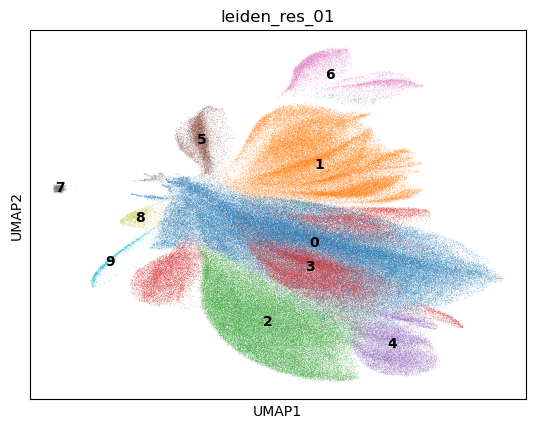

In [21]:
sc.pl.umap(
    adata,
    color="leiden_res_01",# "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)

In [8]:
sc.pp.log1p(adata)

In [22]:
marker_genes = {
    "Astrocytes": ["Aldh1l1", "Aqp4", "Gja1", "Ntsr2"],
    "Excitatory neurons": ["Slc17a7", "2010300C02Rik", "Mef2c", "Neurod6", "Nrn1"],
    "Inhibitory neurons": ["Gad1", "Gad2", "Rab3b", "Btbd11"],
    "Microglia": ["P2ry12", "Siglech", "Tmem119", "Hexb", "Itgam"],
    "OPC": ["Pdgfra", "Vcan", "Cspg4"],
    "Oligodendrocytes": ["Plp1", "Mobp", "Mbp", "Cnp", "Apod"],
    "Pericytes/Endothelial": ["Cldn5", "Ly6a", "Pecam1"], 
    "Fibroblast": ["Dcn", "Aldh1a2", "Slc13a4", "Col1a1"],
}

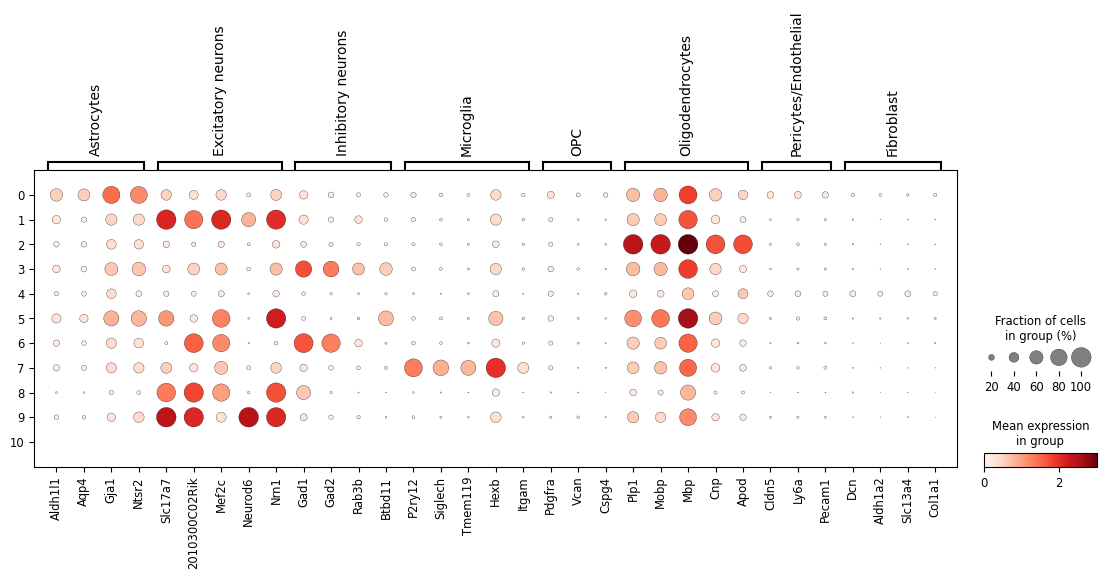

In [25]:
sc.pl.dotplot(adata, var_names=marker_genes,  groupby='leiden_res_02', show=True)

In [9]:
# sc.tl.rank_genes_groups(
#     adata, groupby="leiden_res_01", method="wilcoxon", key_added="dea_leiden_res_01"
# )

In [24]:
# sc.pl.rank_genes_groups_dotplot(
#     adata, groupby="leiden_res_01", standard_scale="var", n_genes=5, key="dea_leiden_res_01"
# )

In [26]:
cluster_annotations = {
    0: "Astrocytes", 
    1: "Excitatory neurons",
    2: "Oligodendrocytes",
    3: "Inhibitory neurons",
    4: "Unknown",
    5: "Mixed Neurons/Oligo",
    6: "Mixed Neurons/Oligo",
    7: "Microglia", 
    8: "Excitatory neurons",
    9: "Excitatory neurons",
    10: "Unknown"
}


In [27]:
adata.obs['celltype'] = adata.obs['leiden_res_02'].astype(int).map(cluster_annotations)

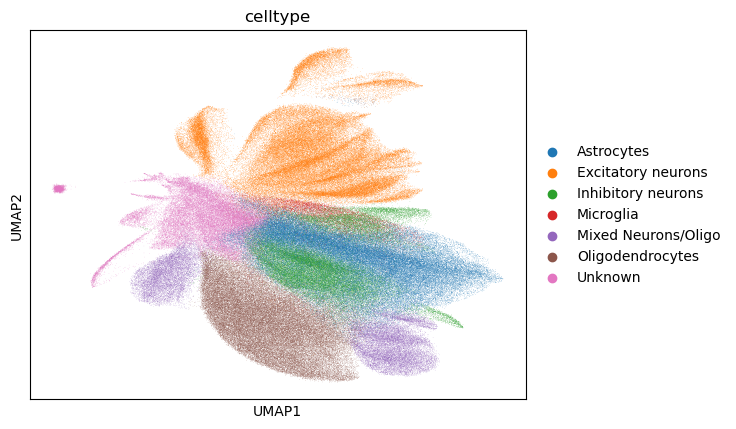

In [28]:
sc.pl.umap(adata, color=["celltype"])

In [18]:
# remove cluster 14
adata = adata[adata.obs['leiden_res0_25'] != "12"]
adata = adata[adata.obs['leiden_res0_25'] != "11"]

In [29]:
adata.write(f'{sample_path}/anndata/xenium_mouse_ad_annotated.h5ad')

In [37]:
adata = ad.read_h5ad(f'{sample_path}/anndata/xenium_mouse_ad_annotated.h5ad')

In [30]:
adata.obs['sample'] = adata.obs['condition'].astype(str) + "_" + adata.obs['time'].astype(str)

In [34]:
#import squidpy as sq

titles = [
    'wildtype 2.5 mo',
    'TgCRND8 2.5 mo',
    'wildtype 5.7 mo',
    'TgCRND8 5.7 mo',
    'wildtype 13.4 mo',
    'TgCRND8 17.9 mo'
]

sc.pl.spatial_scatter(
    adata,
    shape=Nosne,
    library_key='sample',
    color='sample',
    size=1,
    figsize=(15, 15),
    library_id=['wildtype_2_5', 'TgCRND8_2_5', 'wildtype_5_7', 'TgCRND8_5_7', 'wildtype_13_4', 'TgCRND8_17_9'],
    title=titles,
    ncols=2
)

In [40]:
## Sample wildtype_5_7 and TgCRND8_17_9 need 180 rotation

In [35]:
import numpy as np

# Samples that need x-axis flipping
flip_samples = ['wildtype_5_7', 'TgCRND8_17_9']

# Copy current coordinates
coords = adata.obsm['spatial'].copy()

for s in flip_samples:
    mask = adata.obs['sample'] == s
    if mask.any():
        # Compute the vertical flip axis (center along X)
        center_x = coords[mask, 0].mean()
        
        # Flip horizontally: (x, y) → (2*cx - x, y)
        coords[mask, 0] = 2 * center_x - coords[mask, 0]

# Save back
adata.obsm['spatial'] = coords


In [ ]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    library_key='sample',
    color='sample',
    size=1,
    figsize=(15, 15),
    library_id=['wildtype_2_5', 'TgCRND8_2_5', 'wildtype_5_7', 'TgCRND8_5_7', 'wildtype_13_4', 'TgCRND8_17_9'],
    title=titles,
    ncols=2
)

In [36]:
adata.write(f'{sample_path}/anndata/xenium_mouse_ad_annotated_rotated.h5ad')